<a href="https://colab.research.google.com/github/steven030/vehicle-co2-consumption-analysis/blob/main/Distribucion_de_variables_en_Co2_Vehiculo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Distribucion de variables en vehiculos-originales**


Estaremos viendo la distribucion de las variables numericas dentro de nuestro dataset, en el ultimo notebook agrupamos las variables tanto categoricas como continuas y ahora veremos como se distribuyen los datos en estas.

# **Importaremos las librerias de drive y pandas para traer nuestro dataset nativo de pandas el cual es un pkl(pickle).**



In [1]:
from google.colab import drive
import pandas as pd
import os

#declaramos nuestra variable con la ruta + nombre del archivo
path_file = '/content/drive/MyDrive/Colab Notebooks/vehiculos_originales-limpio_analisis_variables_Agrupadas.pkl'

#montamos nuestro disco en drive con el dataset
drive.mount('/content/drive')

if os.path.exists(path_file):
  print("File is imported successfully!")
  #Creamos nuestro DataFrame Pandas desde el archivo pickle en drive
  df_veh = pd.read_pickle(path_file)
else:
  print("The file does not exist!")
  df_veh = pd.DataFrame()




Mounted at /content/drive
File is imported successfully!


In [2]:
#verificamos los tipos de datos de nuestra columna
df_veh.dtypes

,0
Fabricante,object
modelo,object
year,int64
desplazamiento,float64
cilindros,float64
traccion,object
transmision,object
clase,object
combustible,object
consumo,int64


In [3]:
#importamos las librerias de visualizacion graficas como matplotlib y seaborn
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact,fixed

plt.rcParams['figure.figsize'] = (4,2)

Definimos una funcion para graficar estas varibles discretas y su distribucion
en el dataset

In [4]:
def graficarVaribles(title,col,df):
  df[col].plot.kde()
  plt.title(title+str(col))


In [5]:
#definimos las columnas numericas de nuestro dataset
column_num = df_veh.select_dtypes(include=['int64','float64'])


Pondremos nuestra funcion interactica con interact de ipywidgets

In [6]:
interact(graficarVaribles,title="Distribucion de frecuencia de ",col=column_num,df=fixed(df_veh))

interactive(children=(Text(value='Distribucion de frecuencia de ', description='title'), Dropdown(description=…

<function __main__.graficarVaribles(title, col, df)>

Mas abajo podemos ver como se ve una distribucion normal en comparacion con la distribucion de CO2, por lo cual  podemos observar una asimetria positiva ( sesgo hacia la derecha) con una cola que se arrastra hacia los valores altos.


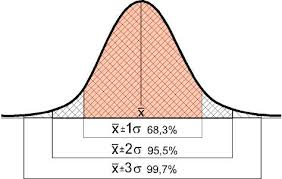

Los valores en la distribucion de CO2 se asemejan al siguiente grafico 1 de la izquierda:


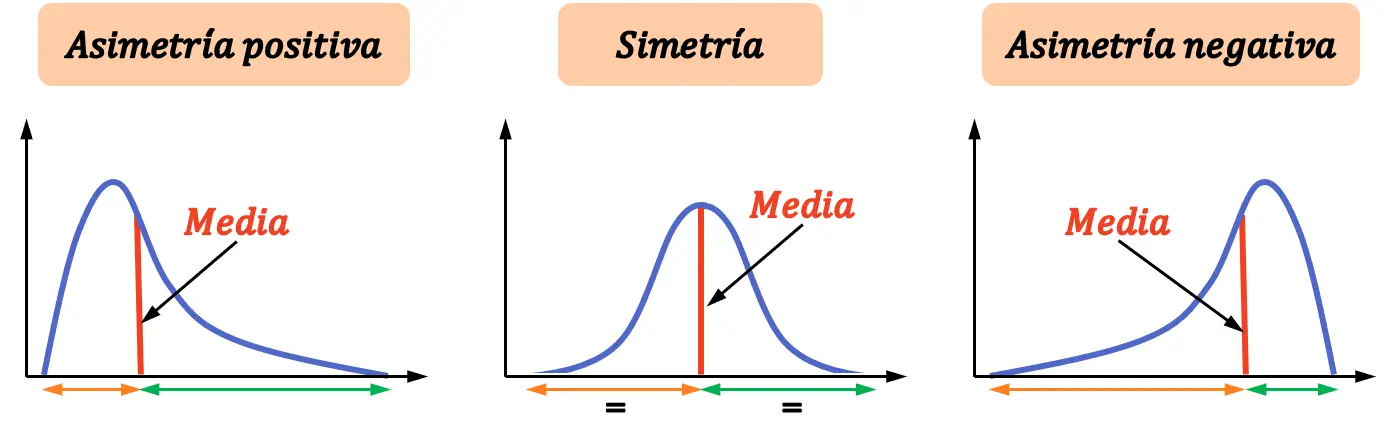

In [7]:
from scipy import stats

def verificar_variable_normal(col):
  stats.probplot(df_veh[col],plot=plt)
  plt.title(f"ver la probabilidad de normalidad en la variable {col}")
  plt.show()


In [8]:
interact(verificar_variable_normal,col=column_num)

interactive(children=(Dropdown(description='col', options=('year', 'desplazamiento', 'cilindros', 'consumo', '…

<function __main__.verificar_variable_normal(col)>

La probabilidad de que la variable sea normar podemos ver que segun la linea se ajusta un 85%

In [9]:
for col_num in column_num:
  _, prov = stats.normaltest(df_veh[col_num])
  if prov < 0.05:
    print(f'la columna {col_num} tiene una distribucion normal.')

la columna year tiene una distribucion normal.
la columna consumo tiene una distribucion normal.
la columna co2 tiene una distribucion normal.
la columna consumo_litros_milla tiene una distribucion normal.
la columna galones_por_milla tiene una distribucion normal.


In [10]:
df_copy = df_veh.select_dtypes(include=['int64','float64'])

In [11]:
#normalizamos la variable de co2 para ver como se comportaria

for column in df_copy:
  df_copy[column] = (df_copy[column] - df_copy[column].min()) / (df_copy[column].max() - df_copy[column].min())

print(df_copy)

           year  desplazamiento  cilindros   consumo       co2  \
0      0.000000        0.243590   0.142857  0.196078  0.398014   
1      0.000000        0.461538   0.285714  0.117647  0.527672   
2      0.029412        0.243590   0.142857  0.176471  0.424351   
3      0.029412        0.461538   0.285714  0.117647  0.527672   
4      0.088235        0.410256   0.285714  0.176471  0.424351   
...         ...             ...        ...       ...       ...   
36786  0.911765        0.051282   0.071429  0.568627  0.173307   
36787  0.941176        0.038462   0.071429  0.549020  0.174919   
36788  0.941176        0.038462   0.071429  0.529412  0.182174   
36789  0.970588        0.038462   0.071429  0.549020  0.176532   
36790  0.970588        0.038462   0.071429  0.529412  0.183786   

       consumo_litros_milla  galones_por_milla  
0                  0.331027           0.331027  
1                  0.475113           0.475113  
2                  0.360294           0.360294  
3          

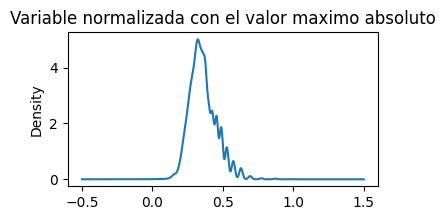

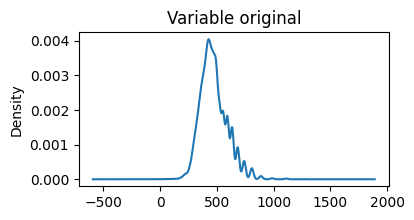

In [12]:
df_copy['co2'].plot.kde()
plt.title('Variable normalizada con el valor maximo absoluto')
plt.show()
df_veh['co2'].plot.kde()
plt.title('Variable original')
plt.show()